# Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

# Step 2: Load Dataset

In [2]:
df = pd.read_csv("GB_Social_Network_Ads.csv")

print(df.shape)

df.head(5)

(400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


# Step 3: Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [4]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


# Step 4: Check Missing Values

In [5]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

# Step 5: Drop User ID

In [6]:
df.drop('User ID', axis = 1, inplace = True)

# Step 6: Target Variable Distribution

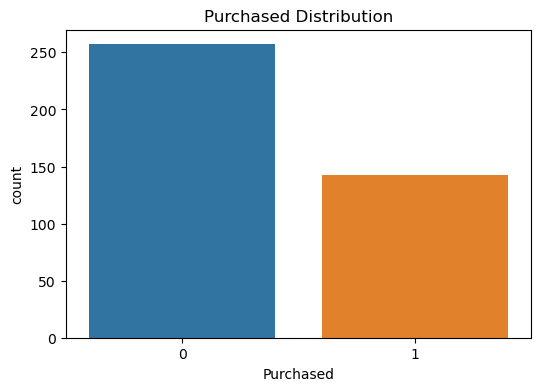

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x="Purchased", data=df)

plt.title("Purchased Distribution")

plt.show()

# Step 7: Purchase Percentage

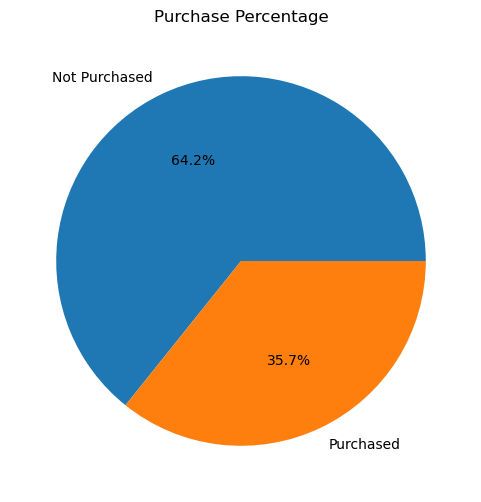

In [9]:
purchase_count = df["Purchased"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    purchase_count,
    labels=["Not Purchased","Purchased"],
    autopct="%1.1f%%"
)

plt.title("Purchase Percentage")

plt.show()

# Step 8: Gender Distribution

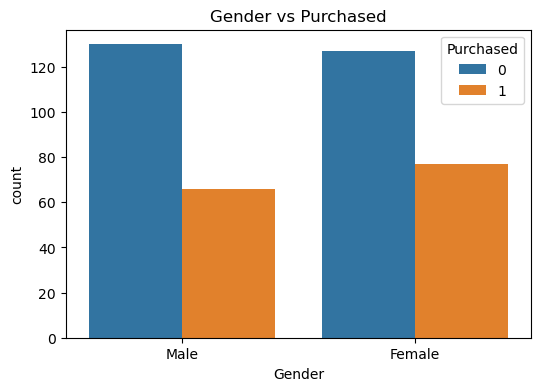

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    hue="Purchased",
    data=df
)

plt.title("Gender vs Purchased")

plt.show()

# Step 9: Age Distribution

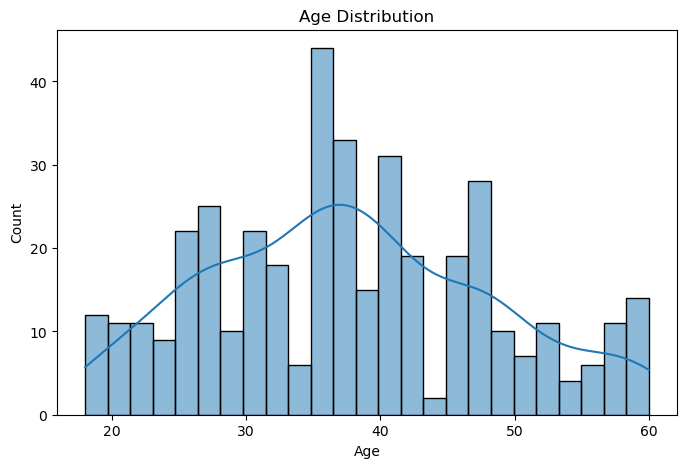

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=25,
    kde=True
)

plt.title("Age Distribution")

plt.show()

# Step 10: Salary Distribution

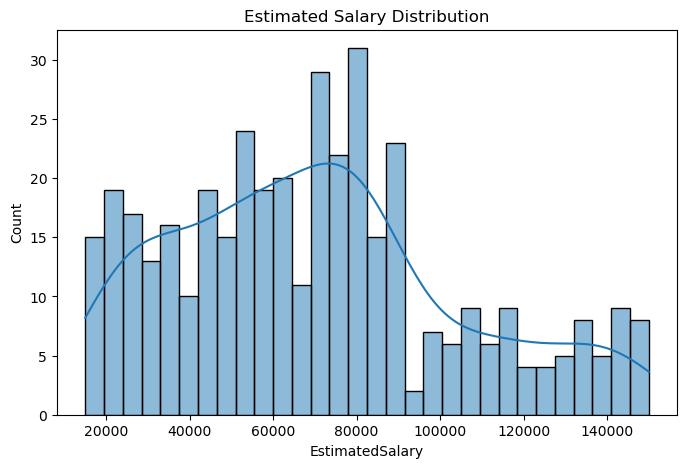

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["EstimatedSalary"],
    bins=30,
    kde=True
)

plt.title("Estimated Salary Distribution")

plt.show()

# Step 11: Age vs Salary Scatter Plot

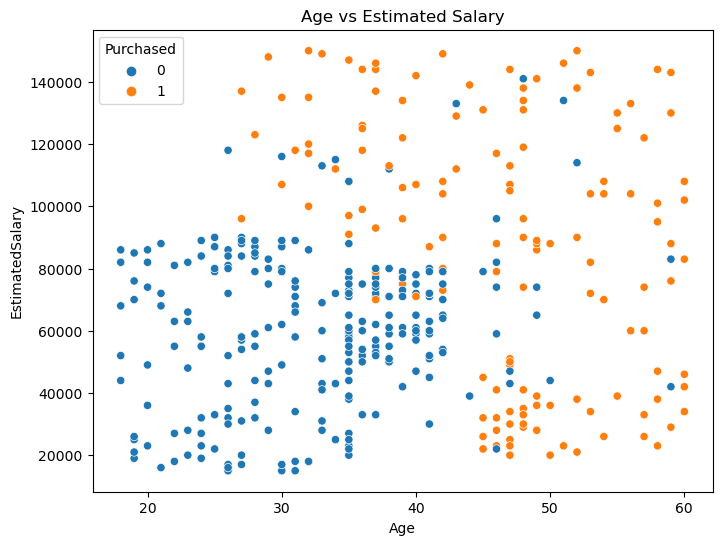

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Age",
    y="EstimatedSalary",
    hue="Purchased",
    data=df
)

plt.title("Age vs Estimated Salary")

plt.show()

# Step 12: Encode Gender

In [14]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


# Step 13: Correlation Heatmap

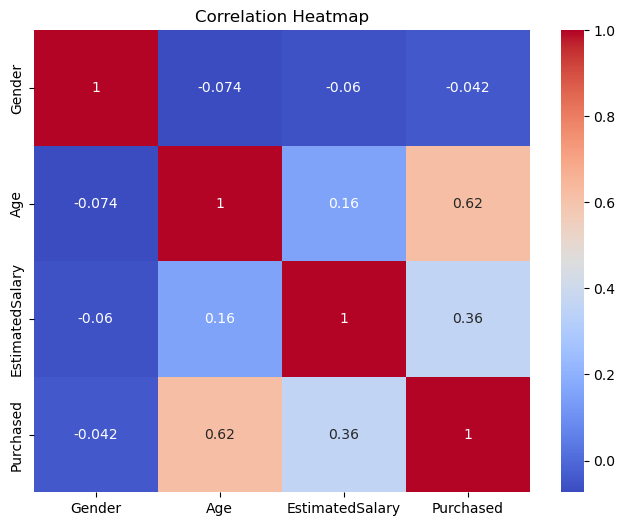

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Step 14: Define Features and Target

In [16]:
X = df.drop("Purchased", axis=1)

y = df["Purchased"]

# Step 15: Feature Scaling

In [17]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

# Step 16: Train Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print(X_train.shape)

print(X_test.shape)

(320, 3)
(80, 3)


# Step 17: Build Gradient Boosting Model

In [19]:
gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

# Step 18: Prediction

In [20]:
y_pred = gb_model.predict(X_test)

y_prob = gb_model.predict_proba(X_test)[:,1]

# Step 19: Accuracy Score

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), "%")

Accuracy : 90.0 %


# Step 20: Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix')

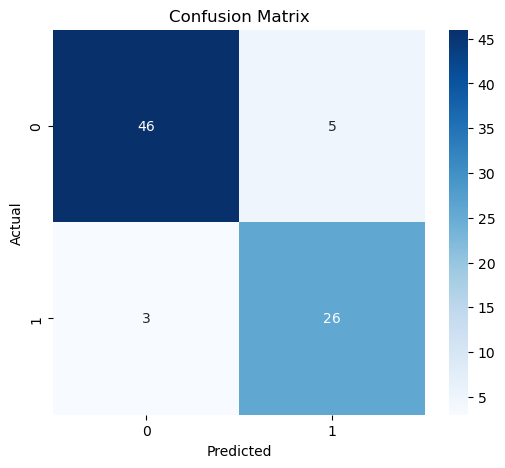

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")


# Step 21: Classification Report

In [23]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



# Step 22: ROC Curve

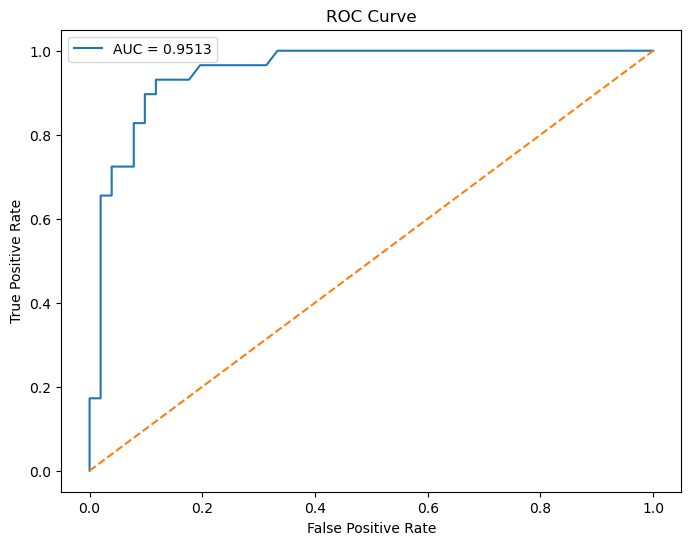

In [25]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# Step 23: AUC Score

In [26]:
print(
    "AUC Score :",
    round(auc_score,4)
)

AUC Score : 0.9513


# Step 24: Feature Importance

In [28]:
feature_names = [
    "Gender",
    "Age",
    "EstimatedSalary"
]

importance = pd.DataFrame({
    "Feature":feature_names,
    "Importance":gb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

           Feature  Importance
1              Age    0.502709
2  EstimatedSalary    0.485846
0           Gender    0.011446


# Step 25: Feature Importance Graph

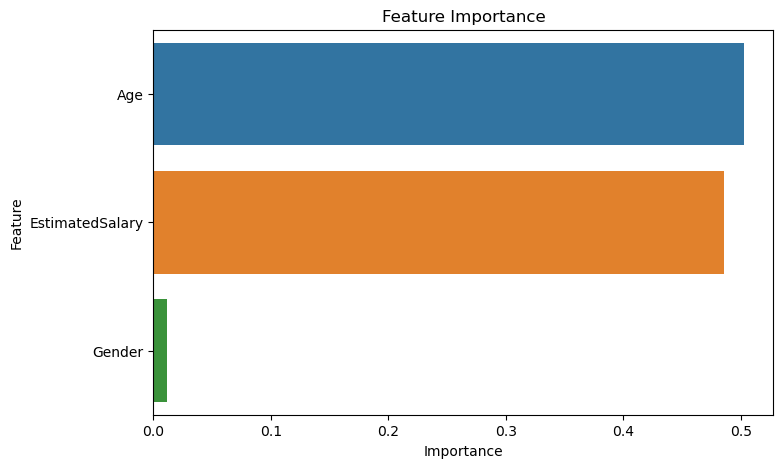

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

# Step 26: Training Accuracy

In [36]:
train_pred = gb_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy :", round(train_acc*100,2), '%')

Training Accuracy : 98.12 %


# Step 27: Testing Accuracy

In [37]:
test_acc = accuracy_score(y_test, y_pred)

print("Testing Accuracy :", round(test_acc*100,2), '%')

Testing Accuracy : 90.0 %


# Step 28: Overfitting Check

In [39]:
difference = train_acc - test_acc

print("Training Accuracy :", round(train_acc*100,2), '%')

print("Testing Accuracy :", round(test_acc*100,2), "%")

print("Difference :", round(difference*100,2), '%')

Training Accuracy : 98.12 %
Testing Accuracy : 90.0 %
Difference : 8.12 %


# Step 29: Actual vs Predicted

In [40]:
results = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

results.head(20)

,Actual,Predicted
331,1,1
92,0,0
1,0,0
234,0,1
136,0,0
356,1,1
122,0,0
223,1,1
64,0,1
398,0,0


# Step 30: Purchase Probability

In [41]:
probability_df = pd.DataFrame({
    "Actual":y_test,
    "Purchase_Probability":y_prob
})

probability_df.head(20)

,Actual,Purchase_Probability
331,1,0.908037
92,0,0.002442
1,0,0.002712
234,0,0.883748
136,0,0.007764
356,1,0.990425
122,0,0.027743
223,1,0.997073
64,0,0.987743
398,0,0.012648


# Step 31: Save Model

In [42]:
import joblib

joblib.dump(
    gb_model,
    "GradientBoosting_SocialNetworkAds.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
